In [19]:
#Import statements

from data_utils import load_dataset
import data_utils
import numpy as np
import matplotlib.pyplot as plt
import math
import a3_mod

%matplotlib inline

In [20]:
#Helper functions used for question 1

#This function calculates the sigmoid given an input
def sig(z):
    return 1.0/(1+np.exp(-z))

#This function calculates the loss given the weights, the x data, and y data as input
def loss_func(w,x,y,sigma=1.0):
    f = sig(np.dot(x,w)) #Calculates f
    nll = -np.sum(y*np.log(f)+(1-y)*np.log(1-f)) #Calculates the negative log-likelihood
    nlp = np.dot(w.squeeze(),w.squeeze())/(2*sigma) #Calculates the negative log-prior
    return nll + nlp #Returns the sum of the negative log-likelihood and negative log-prior

#This function calculates the log likelihood given the weights, the x data, and y data as input
def log_likelihood(w,x,y,sigma=1.0):
    f = sig(np.dot(x,w)) #Calculates f
    ll = np.sum(y*np.log(f)+(1-y)*np.log(1-f)) #Calculates the log-likelihood
    return ll

#This function calculates the gradient for full batch gradient descent given the weights, the x data, and y data as input
def GD_grad(w,x,y,sigma=1.0):
    f = sig(np.dot(x,w)) #Calculates f
    nll_grad = -np.sum((y-f)*x,axis=0).reshape(-1,1) #Calculates gradient of the negative log-likelihood
    nlp_grad = w/(sigma**2) #Calculates gradient of the log-prior
    return nll_grad + nlp_grad #Returns the sum of the negative log-likelihood gradient and negative log-prior gradient

#This function calculates the gradient for stochastic gradient descent given the weights, the x data, and y data as input
def SGD_grad(w,x,y,N,sigma=1.0):
    f = sig(np.dot(x,w)) #Calculates f
    nll_grad = -N*np.sum((y-f)*x,axis=0).reshape(-1,1)
    nlp_grad = 0 
    return nll_grad + nlp_grad #Calculates gradient for stochastic gradient descent

In [21]:
#Function used to answer question 1 and takes in the learning rate for full batch gradient descent and number of epochs, and the
#value of the random seed as input.

#Outputs include the test accuracy and test log-likelihood for both full batch gradient descent and stochastic gradient descent 
#and plot of the loss for both full batch gradient descent and stochastic gradient descent per epoch.

def Question_1(lr, epochs, seed):
    
    np.random.seed(seed)
    
    #Load dataset and perform data processing
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('iris')
    y_train, y_valid, y_test = y_train[:,1,None], y_valid[:,1,None], y_test[:,1,None]
    
    x_train = np.vstack([x_valid, x_train])
    y_train = np.vstack([y_valid, y_train])
    
    #Record dataset parameters
    N_train = len(x_train)
    N_test = len(x_test)
    
    #Add ones as bias
    train_bias = np.ones((N_train,1))
    x_train = np.hstack([train_bias, x_train])
    test_bias = np.ones((N_test,1))
    x_test = np.hstack([test_bias, x_test])

    D = len(x_train[0])
    
    #Initialize variables
    lowest_loss = float('inf')
    GD_losses = []
    
    GD_best_w = None
    
    w = np.zeros((D,1))

    #Full batch gradient descent
    for i in range(epochs):
        
        #Calculate gradient
        grad = GD_grad(w,x_train,y_train)
        
        #Update weights
        w = w - grad*lr
        
        #Calculate loss
        loss = loss_func(w,x_train,y_train)
        GD_losses += [loss]
        
        if loss < lowest_loss:
            GD_best_w = w
            lowest_loss = loss
            
    #Initialize variables
    lowest_loss = float('inf')
    SGD_losses = []
    
    SGD_best_w = None

    w = np.zeros((D,1))
    
    #Start Stochastic Gradient Descent
    for i in range(0,epochs):
        
        #Loop through length of dataset
        for t in range(0,N_train):
            
            #Select index of data point
            t = np.random.choice(N_train, size=(1,))
            
            #Calculate gradient
            gradient = SGD_grad(w,x_train[t],y_train[t],N_train)
            
            #Update weights
            w = w - gradient*lr/N_train
            
            #Calculate loss
            loss = loss_func(w,x_train,y_train)

            #Update best weight and loss
            if loss < lowest_loss:
                SGD_best_w = w
                lowest_loss = loss
        
        SGD_losses += [loss]

    #Plot loss curve per epoch
    plt.figure()
    plt.plot(GD_losses)
    plt.plot(SGD_losses)
    plt.xlabel("Epoch")
    plt.ylabel('Loss')
    plt.title('Full Batch Gradient Descent vs Stochastic Gradient Descent Loss Per Epoch')
    plt.legend(['Full Batch Gradient Descent','Stochastic Gradient Descent'])
    

    #Generate predictions over test set
    GD_prediction = sig(np.dot(x_test,GD_best_w))>0.5
    SGD_prediction = sig(np.dot(x_test,SGD_best_w))>0.5
    
    #Calculate Accuracy
    
    GD_num_correct = 0
    SGD_num_correct = 0
    
    for i in range(0,N_test):
        if GD_prediction[i][0] == y_test[i][0]:
            GD_num_correct += 1
        if SGD_prediction[i][0] == y_test[i][0]:
            SGD_num_correct += 1
    
    GD_accuracy = GD_num_correct/N_test
    SGD_accuracy = SGD_num_correct/N_test
    
    #Print Statistics

    print('Test Accuracy from Full Batch Gradient Descent: ' + str(GD_accuracy))
    print('Test Log-likelihood from Full Batch Gradient Descent:',log_likelihood(GD_best_w,x_test,y_test))
    
    print('Test Accuracy from Stochastic Gradient Descent: ' + str(SGD_accuracy))
    print('Test Log-likelihood from Stochastic Gradient Descent:', log_likelihood(SGD_best_w,x_test,y_test))
    
    return

In [22]:
#Function used to answer question 2 and takes in the learning rate for stochastic gradient descent, number of iterations,
#the probability threshold for displaying images, and value of random seed as input.

#Outputs include test negative log-likelihood, test accuracy, indices of uncertain predictions from the test set, a plot
#comparing training and validation data negative log-likelihood per iteration and the images of the uncertain predictions
#from the test set.

def Question_2(SGD_lr, SGD_iterations, probability_threshold, seed):
    
    np.random.seed(seed)
    
    #Load dataset
    x_train, x_valid, x_test, y_train, y_valid, y_test = load_dataset('mnist_small')
    
    #Record dataset parameters
    N_train = len(x_train)
    N_valid = len(x_valid)
    N_test = len(x_test)
    D = len(x_train[0])
   
    # Initialize the weights and biases of the train network
    M = 100 # 100 neurons per hidden layer
    W1 = np.random.randn(M, 784) / np.sqrt(784/2) # Weights of first (hidden) layer initialized using ReLU initialization
    W2 = np.random.randn(M, M) / np.sqrt(M/2) # Weights of first (hidden) layer initialized using ReLU initialization
    W3 = np.random.randn(10, M) / np.sqrt(M) # Weights of first (hidden) layer initialized using Xavier initialization
    b1 = np.zeros((M, 1)) # Biases of first (hidden) layer
    b2 = np.zeros((M, 1)) # Biases of second (hidden) layer
    b3 = np.zeros((10, 1)) # Biases of third (output) layer
    
    #Initialize variables
    train_nlls = []
    valid_nlls = []
    
    best_loss = float('inf')
    best_W1 = None
    best_W2 = None
    best_W3 = None
    best_b1 = None
    best_b2 = None
    best_b3 = None
    
    #Start Stochastic Gradient Descent
    for i in range(0, SGD_iterations):
        
        remainder = i%(N_train/250)
        
        #Calculate boundaries for batch
        lower = int(250*remainder)
        upper = int(250*(remainder + 1))
        
        #Reshuffle data every epoch
        if remainder == 0:
            train_data = np.hstack([x_train, y_train])
            np.random.shuffle(train_data)
            x_train = train_data[:,:D]
            y_train = train_data[:,D:]
    
        #Calculate gradients and negative log-likelihood
        (nll, (W1_grad, W2_grad, W3_grad, b1_grad, b2_grad, b3_grad)) = \
            a3_mod.nll_gradients(W1, W2, W3, b1, b2, b3, x_train[lower:upper], y_train[lower:upper])
        
        train_nlls += [nll]
        
        #Calculate validation log-likelihood
        valid_nll = a3_mod.negative_log_likelihood(W1, W2, W3, b1, b2, b3, x_valid, y_valid)
        valid_nlls += [valid_nll]
        
        #Save weights if the validation loss is the current best
        if valid_nll<best_loss:
            best_loss = valid_nll
            best_W1 = W1
            best_W2 = W2
            best_W3 = W3
            best_b1 = b1
            best_b2 = b2
            best_b3 = b3
            
        #Gradient descent update
        W1 = W1 - SGD_lr*W1_grad
        W2 = W2 - SGD_lr*W2_grad
        W3 = W3 - SGD_lr*W3_grad
        b1 = b1 - SGD_lr*b1_grad
        b2 = b2 - SGD_lr*b2_grad
        b3 = b3 - SGD_lr*b3_grad
    
    #Plot negative log-likelihood for training and validation data per iteration
    plt.plot(train_nlls)
    plt.plot(valid_nlls)
    plt.xlabel('Iterations')
    plt.ylabel('Negative Log-Likelyhood')
    plt.title('Training vs Validation Data Negative Log-Likelyhood Per Iteration')
    plt.legend(['Training Data','Validation Data'])
    
    #Calculate negative log-likelihood for the test set
    nll = a3_mod.negative_log_likelihood(best_W1, best_W2, best_W3, best_b1, best_b2, best_b3, x_test, y_test)
    
    #Calculate the probability of each class performing a forward pass and taking the exponential
    probabilities = np.exp(a3_mod.forward_pass(best_W1, best_W2, best_W3, best_b1, best_b2, best_b3, x_test))
    
    #Calculate the max probability class for each data point
    max_probability = np.amax(probabilities, axis = 1)
    
    #Calculate the prediction for each data point
    predictions = np.argmax(probabilities, axis = 1)
    
    #Calculate accuracy for the test set
    num_correct = 0
    for i in range(0,N_test):
        if y_test[i][predictions[i]] == True:
            num_correct += 1
    
    accuracy = num_correct/N_test
    
    #Print Statistics
    print("Negative Log-Likelyhood: " + str(nll))
    print("Accuracy: " + str(accuracy))
    
    #Find predictions that the model was uncertain about by finding data points that had probability less than 0.0008
    bad_predictions = []
    for i in range(0,len(max_probability)):
        if max_probability[i]<probability_threshold:
            bad_predictions += [i]
            
    print("Bad Prediction Indices: " + str(bad_predictions))

    #Print the images for the uncertain data points
    for i in bad_predictions:
        plt.figure()
        data_utils.plot_digit(x_test[i])
    
    return

Test Accuracy from Full Batch Gradient Descent: 0.7333333333333333
Test Log-likelihood from Full Batch Gradient Descent: -7.154066132310388
Test Accuracy from Stochastic Gradient Descent: 0.7333333333333333
Test Log-likelihood from Stochastic Gradient Descent: -7.2255816315177235


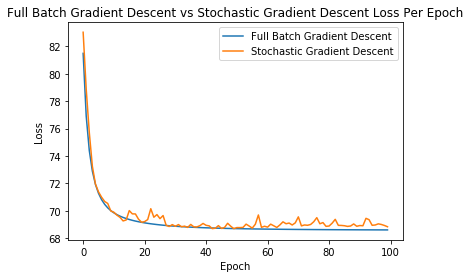

In [23]:
#Code used for Question 1

#To use, the learning rate for full batch gradient descent, number of epochs and the random seed value can be changed as desired
#The default values were used to find the results given in the report.

lr = 0.01
epochs = 100
seed = 0

Question_1(lr,epochs,seed)

#Results

#Test Accuracy from Full Batch Gradient Descent: 0.7333333333333333
#Test Log-likelihood from Full Batch Gradient Descent: -7.154066132310388
#Test Accuracy from Stochastic Gradient Descent: 0.7333333333333333
#Test Log-likelihood from Stochastic Gradient Descent: -7.2255816315177235

Negative Log-Likelyhood: 4832.788778189771
Accuracy: 0.959
Bad Prediction Indices: [203, 289, 488, 581, 724]


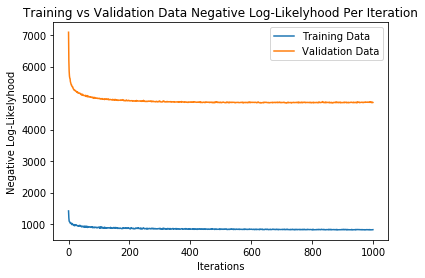

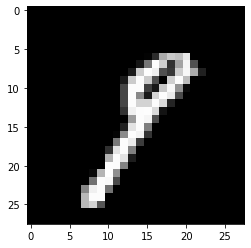

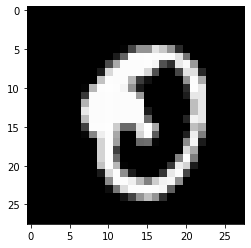

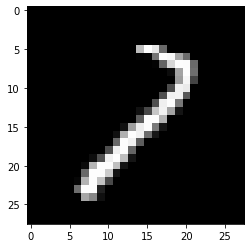

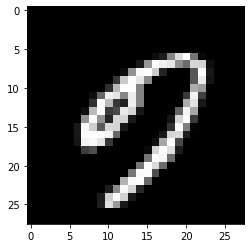

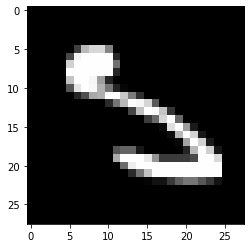

In [26]:
#Code used for Question 2

#To use, the learning rate for stochastic gradient descent and number of iterations can be changed as desired.
#The default values were used to find the results given in the report.

SGD_lr = 0.001
iterations = 1000
probability_threshold = 0.0008
seed = 0
Question_2(SGD_lr, iterations, probability_threshold, seed)

#Results

#Negative Log-Likelyhood: 4832.788778189771
#Accuracy: 0.959
#Bad Prediction Indices: [203, 289, 488, 581, 724]